In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model, load_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import urllib.request
from matplotlib import font_manager

In [12]:
!mkdir -p /kaggle/working/merged_data

In [13]:
!cp -r /kaggle/input/bangla-alphabet/splitted/train/* /kaggle/working/merged_data/
!cp -r /kaggle/input/bangla-alphabet/splitted/val/*   /kaggle/working/merged_data/
!cp -r /kaggle/input/bangla-alphabet/splitted/test/*  /kaggle/working/merged_data/


In [14]:
sdir=r'/kaggle/working/merged_data'
slist=os.listdir(sdir)
classes=[]
filepaths=[]
labels=[]
for d in slist:
    dpath=os.path.join(sdir, d)
    if os.path.isdir(dpath):
        classes.append(d)
class_count=len(classes)
for klass in classes:
    classpath=os.path.join(sdir,klass)
    filelist=os.listdir(classpath)
    for f in filelist:
        fpath=os.path.join(classpath, f)
        filepaths.append(fpath)
        labels.append(klass)
print ('number of files: ', len(filepaths), '   number of labels: ', len(labels))
file_series=pd.Series(filepaths, name='filepaths')
label_series=pd.Series(labels, name='labels')
df=pd.concat([file_series, label_series], axis=1)
print (df.head())

number of files:  20522    number of labels:  20522
                                 filepaths labels
0  /kaggle/working/merged_data/র/র 231.png      র
1  /kaggle/working/merged_data/র/র 229.png      র
2  /kaggle/working/merged_data/র/র 267.png      র
3  /kaggle/working/merged_data/র/র 171.png      র
4   /kaggle/working/merged_data/র/র 49.png      র


In [15]:
balance=df['labels'].value_counts()
print (balance)

labels
থ     435
দ     433
ড     427
ঞ     427
ট     424
জ     423
ঝ     422
ণ     421
ঠ     420
ন     419
ব     418
আ     418
অ     417
গ     417
ঐ     416
ঢ     415
ঔ     414
ও     414
ছ     414
এ     413
প     413
র     412
খ     412
ম     412
ঈ     412
হ     412
ভ     411
ঙ     411
ই     410
ৎ     410
ড়    409
ধ     409
য়    407
ল     406
ক     405
উ     404
ঘ     404
স     403
৺     403
চ     402
ঃ     402
ত     402
ফ     400
ঢ়    399
ঋ     399
ং     398
য     396
ঊ     388
ষ     387
শ     377
Name: count, dtype: int64


In [16]:
train_split=.8
test_split=.1
dummy_split=test_split/(1-train_split)
train_df, dummy_df=train_test_split(df, train_size=train_split, shuffle=True, random_state=125)
test_df, valid_df= train_test_split(dummy_df, train_size=dummy_split, shuffle=True, random_state=125)
print ('train size: ', len(train_df), '  test size: ', len(test_df), '   valid size: ', len(valid_df))
length=len(test_df)

train size:  16417   test size:  2052    valid size:  2053


In [17]:
batch_size=16
def scalar(x):
    return x/127.5-1 # rescales pixels to range -1 to +1

trgen=tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=scalar, horizontal_flip=True)
train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=(224,224), class_mode='categorical',
                                   batch_size=batch_size, shuffle=True, seed=123)

tvgen=tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=scalar)
valid_gen=tvgen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=(224,224), class_mode='categorical',
                                   batch_size=batch_size, shuffle=False)

# determine test generator batch size and steps to go through the test set exactly once for predictions
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=batch_size],reverse=True)[0]
test_steps=int(length/test_batch_size)
test_gen=tvgen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=(224,224), class_mode='categorical',
                                   batch_size=test_batch_size, shuffle=False)
test_labels=test_gen.labels

Found 16417 validated image filenames belonging to 50 classes.
Found 2053 validated image filenames belonging to 50 classes.
Found 2052 validated image filenames belonging to 50 classes.


In [18]:
# Build classification model using pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(224,224,3), pooling='avg')
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
predictions = tf.keras.layers.Dense(class_count, activation='softmax')(x)
model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

I0000 00:00:1769368373.359301      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769368373.363209      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Callbacks for training
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)

In [20]:
# Train the model with tuned parameters
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=15,  # Increase epochs for better convergence
    batch_size=16,  # Ensure batch size matches the generator
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1769368380.423305     172 service.cc:152] XLA service 0x7e051400fb00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769368380.423362     172 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769368380.423369     172 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769368381.462518     172 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-25 19:13:08.887619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal

 611/1027 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1138 - loss: 3.5122

2026-01-25 19:13:31.887196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:13:32.033863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:13:32.167785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1027/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1603 - loss: 3.2440

2026-01-25 19:13:56.088360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:13:56.224470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1027/1027 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.1604 - loss: 3.2435 - val_accuracy: 0.5611 - val_loss: 1.6307 - learning_rate: 0.0010
Epoch 2/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.4611 - loss: 1.8023 - val_accuracy: 0.6473 - val_loss: 1.2583 - learning_rate: 0.0010
Epoch 3/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.5447 - loss: 1.5100 - val_accuracy: 0.6873 - val_loss: 1.1269 - learning_rate: 0.0010
Epoch 4/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.5930 - loss: 1.3359 - val_accuracy: 0.6907 - val_loss: 1.0294 - learning_rate: 0.0010
Epoch 5/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.6253 - loss: 1.2250 - val_accuracy: 0.7092 - val_loss: 0.9716 - learning_rate: 0.0010
Epoch 6/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.6369 - loss: 1.1748 - val_accuracy: 0.7048 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 7/15
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.6526 

In [21]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,6))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

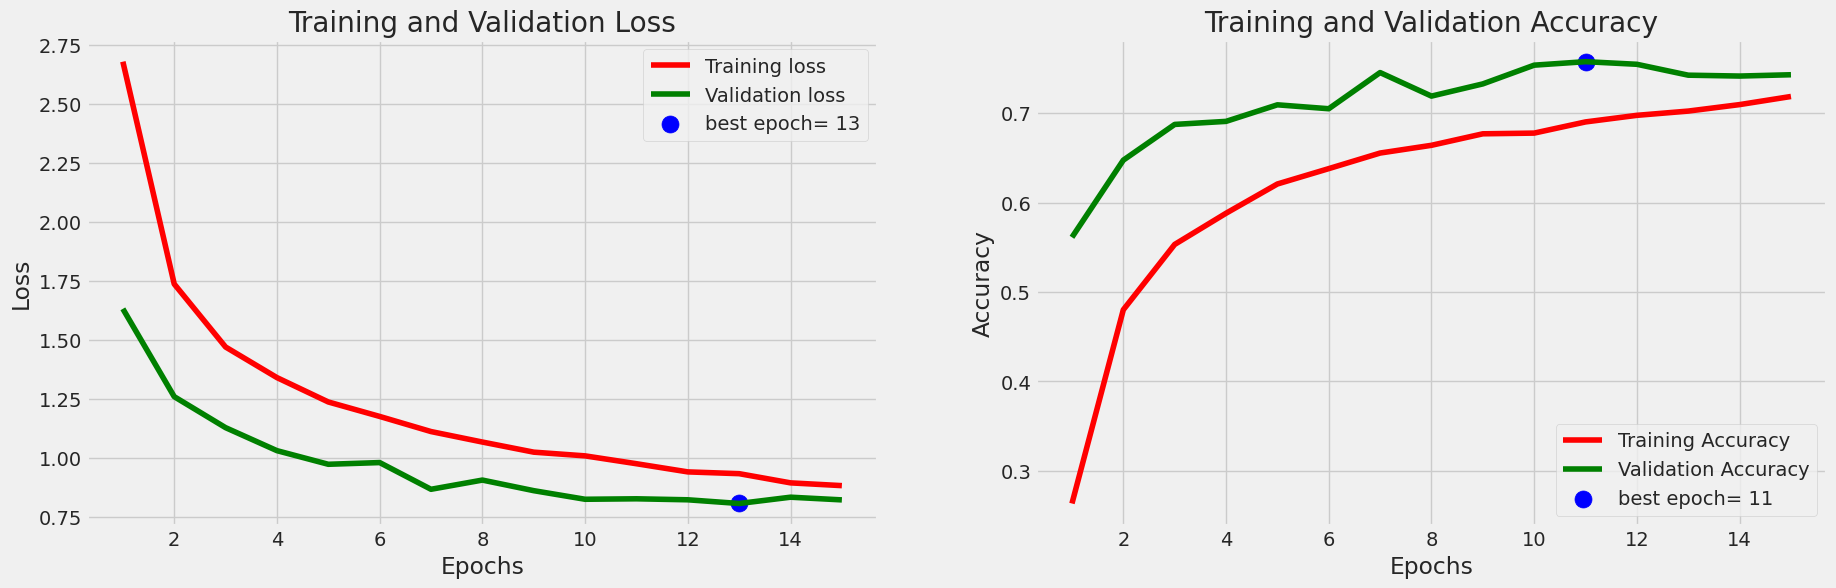

In [22]:
# Plot training results
tr_plot(history, 0)

171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Confusion Matrix
Classification Report
              precision    recall  f1-score   support

           ং       0.69      0.77      0.73        47
           ঃ       0.86      1.00      0.93        44
           অ       0.72      0.92      0.80        36
           আ       0.92      0.84      0.88        43
           ই       0.51      0.76      0.61        46
           ঈ       0.69      0.66      0.68        38
           উ       0.56      0.22      0.32        41
           ঊ       0.47      0.82      0.60        33
           ঋ       0.82      0.84      0.83        43
           এ       0.92      0.83      0.88        42
           ঐ       0.77      0.57      0.66        42
           ও       0.70      0.86      0.77        37
           ঔ       0.69      0.64      0.67        42
           ক       0.86      0.86      0.86        44
           খ       0.83      0.67      0.74        43
           গ       0.88      0.69      0.77        54


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2435 (\N{BENGALI SIGN VISARGA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist

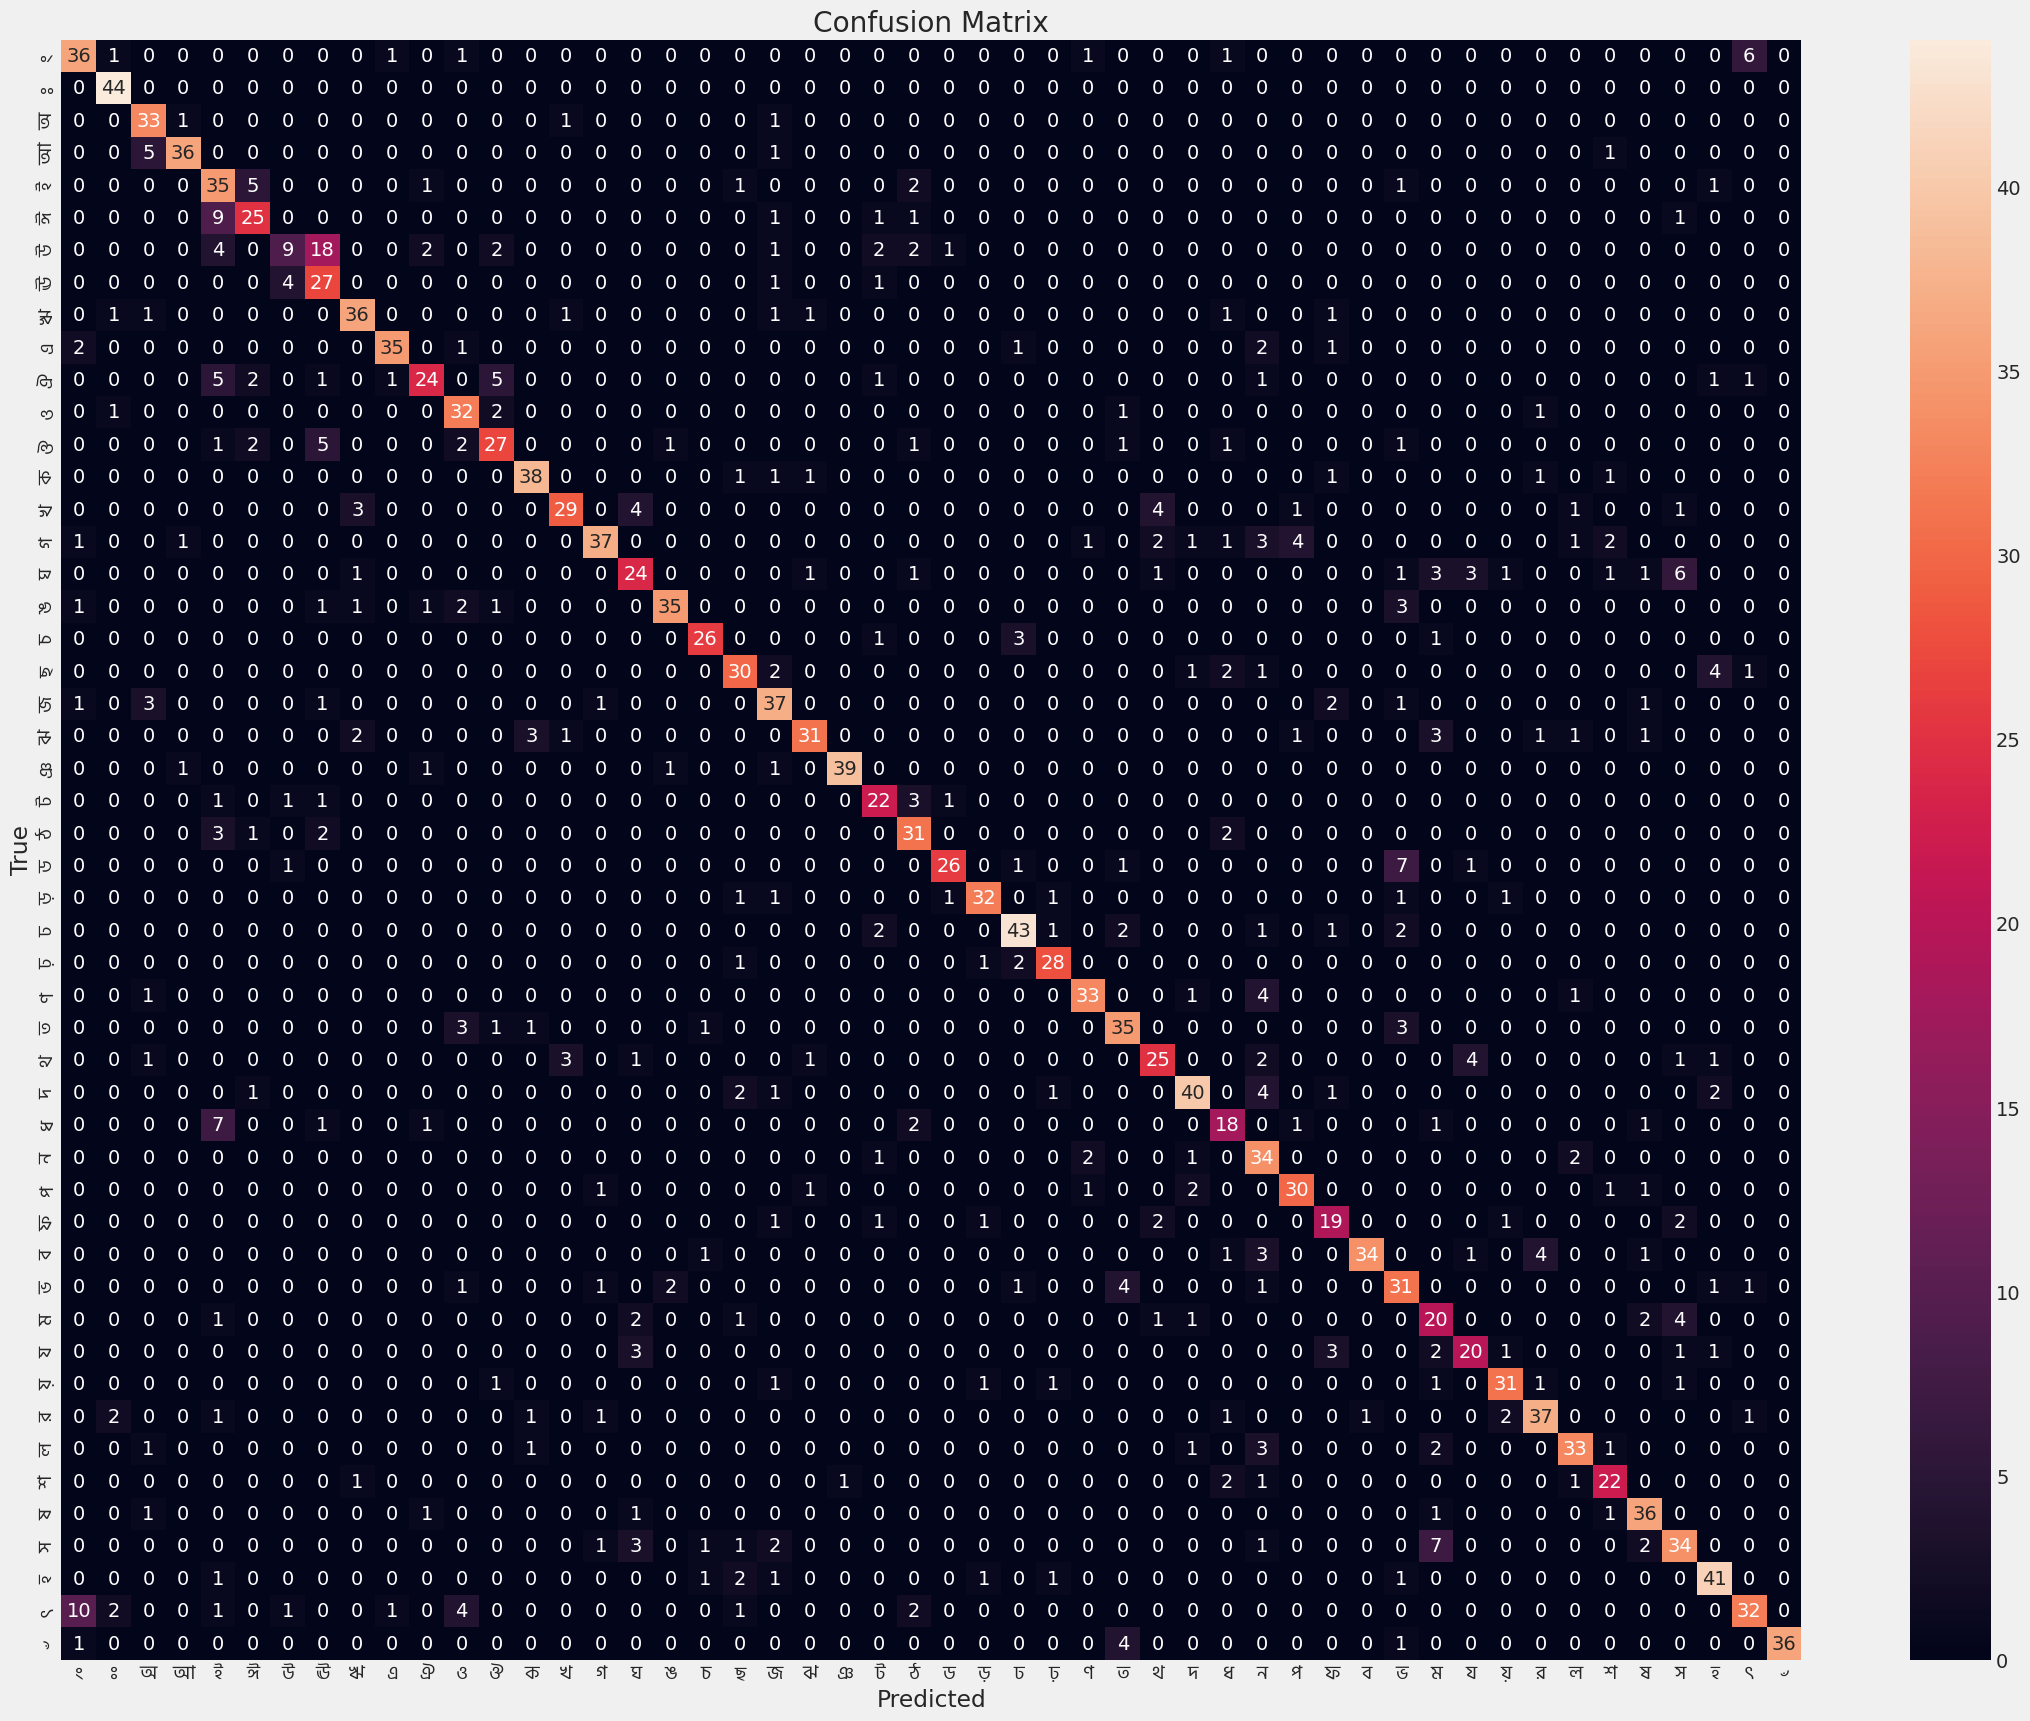

In [24]:
# --- ADDITION 1: FONT DOWNLOAD ---
font_url = "https://github.com/google/fonts/raw/main/ofl/hindsiliguri/HindSiliguri-Regular.ttf"
font_path = "HindSiliguri-Regular.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
bangla_font = font_manager.FontProperties(fname=font_path)

# --- YOUR ORIGINAL LOGIC (Unchanged) ---
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
class_names = list(test_gen.class_indices.keys())
print('Confusion Matrix')
cm = confusion_matrix(test_labels, y_pred)
print('Classification Report')
print(classification_report(test_labels, y_pred, target_names=class_names))

# --- ADDITION 2: SIZE & SCALING ---
plt.figure(figsize=(25, 20)) # Increased size for 50 classes

# --- MODIFIED HEATMAP CALL ---
ax = sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)

# --- ADDITION 3: BANGLA LABEL FIX ---
for label in ax.get_xticklabels():
    label.set_fontproperties(bangla_font)
for label in ax.get_yticklabels():
    label.set_fontproperties(bangla_font)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()